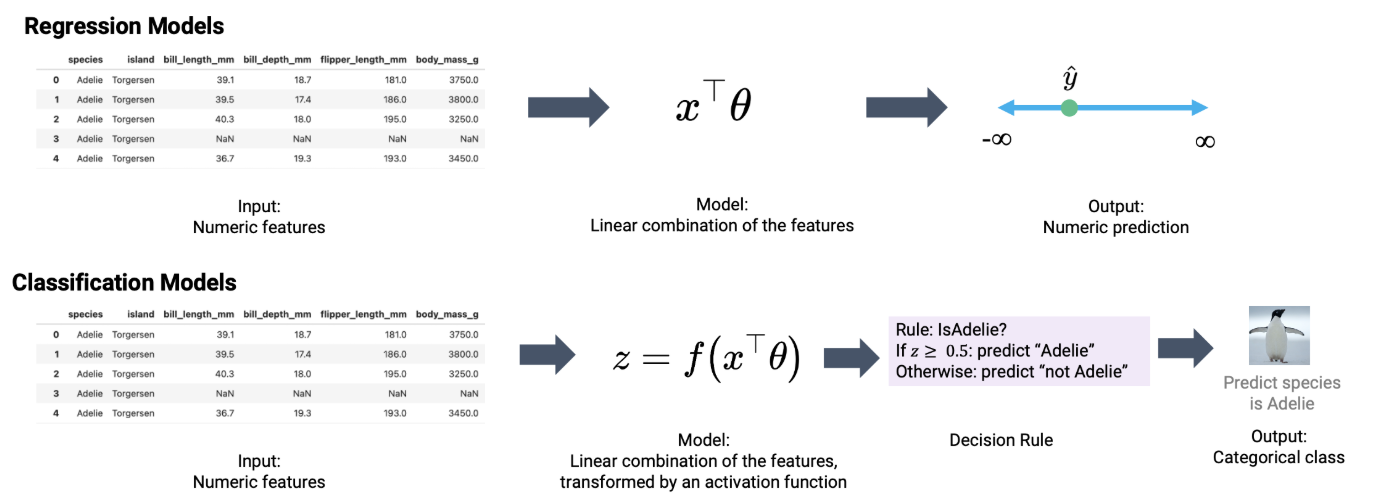
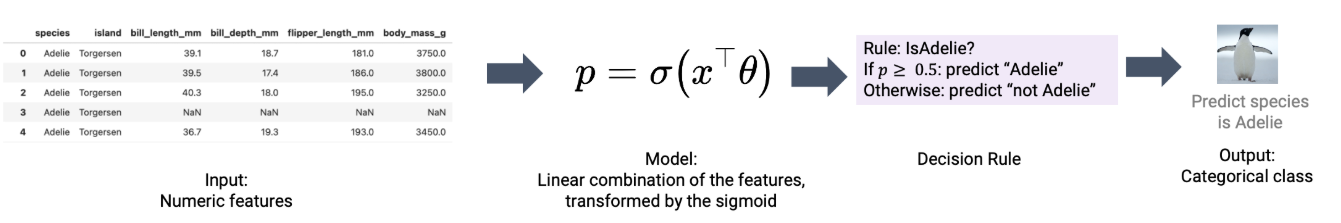

#### What is the Likelihood?

- Suppose we have $n$ data points.
- For each point $i$, the model predicts a probability $P_i$ that the label is 1.
- The actual label $y_i$ is either 0 or 1.

The likelihood function is the **product of the probabilities of the observed labels** given the model’s predictions:

$$
L(\beta_0, \beta_1) = \prod_{i=1}^n P_i^{y_i} (1 - P_i)^{1 - y_i}
$$


- In logistic regression, for each data point there is a predicted probability ($P_i$) and an observed label ($y_i$), which is 1 for “success” (e.g. passed) and 0 for “failure” (e.g. failed).
- The probability of seeing an outcome, given a prediction, is:
  - $P_i$ if $y_i = 1$
  - $1 - P_i$ if $y_i = 0$
- To get the probability of observing the **entire dataset** (i.e., all outcomes) **assuming independence** (each data point is unrelated to the others), we multiply the probabilities:
$$
L = \prod_{i=1}^n P_i^{y_i} (1-P_i)^{1-y_i}
$$
- This product is called the **likelihood function** — it quantifies how likely the observed data are, given model parameters.




- The likelihood function is often very small (since probabilities < 1, multiplying many together gets smaller).
- **Logs** turn products into sums:
$$
\log L = \sum_{i=1}^n [y_i \log P_i + (1 - y_i)\log(1 - P_i)]
$$
- Maximizing likelihood ≡ maximizing log-likelihood (monotonically related).

**Negative Log-Likelihood (NLL):**
- Most optimization algorithms **minimize**, so we minimize the negative log-likelihood (NLL):
$$
\text{NLL} = - \sum_{i=1}^n [y_i \log P_i + (1 - y_i)\log(1 - P_i)]
$$
- Minimizing NLL finds parameters that make predicted probabilities match the observed outcomes as closely as possible.

#### Likelihood Function for Hours_Studied & Passed Example

Suppose we have a dataset where the goal is to predict whether a student passed ($y=1$) or failed ($y=0$) based on the number of hours they studied.

For each student $i$, the model predicts the probability $P_i$ that they passed:

$$
P_i = \frac{1}{1+\exp(-(\beta_0 + \beta_1 \cdot \text{Hours}_i))}
$$

The **likelihood function** multiplies:
- $P_i$ for each student who passed.
- $1-P_i$ for each student who failed.


#### Optimization
   - Calculating this product for every possible combination of $\beta_0$ and $\beta_1$ is not practical.
   - Instead, the **negative log-likelihood** is minimized using numerical optimization algorithms (like those in `scipy.optimize.minimize`).
   - The algorithm automatically searches for the values of $\beta_0$ and $\beta_1$ that make the observed data most probable under the model.

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression

import statsmodels.api as sm

In [4]:
sample = pd.read_csv('./pass.txt')
sample.head()

,Hours,Attendance,Passed
0,1.0,40,0
1,1.2,45,0
2,1.4,50,0
3,3.0,60,0
4,3.5,65,0


In [5]:
X = sample.drop(['Passed', 'Attendance'], axis = 1)
y = sample['Passed']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((14, 1), (6, 1), (14,), (6,))

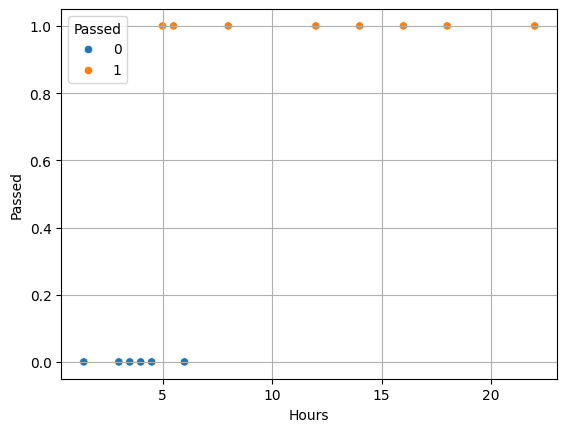

In [7]:
sns.scatterplot(x = X_train.squeeze(), y = y_train, hue = y_train)
plt.grid()

<Axes: xlabel='Hours', ylabel='Passed'>

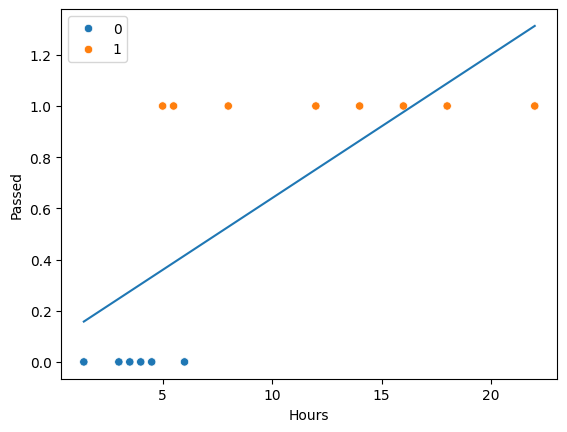

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
sns.scatterplot(x = X_train.squeeze(), y = y_train, hue = y_train)
sns.lineplot(x = X_train.squeeze(), y = lr.predict(X_train))

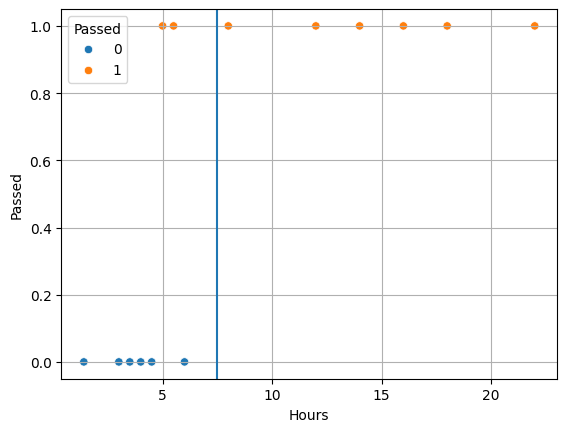

In [9]:
sns.scatterplot(x = X_train.squeeze(), y = y_train, hue = y_train)
plt.axvline(7.5)
plt.grid()

#### Likelihood Function in Logistic Regression

In logistic regression, the goal is to find the best-fitting parameters $\beta_0$ and $\beta_1$ that maximize the likelihood of observing the given data.





In [11]:
logr = LogisticRegression()
logr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
y_train_pred = logr.predict(X_train)
y_train_pred

array([0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0])

In [14]:
logr.predict_proba(X_train)

array([[9.75630407e-01, 2.43695934e-02],
       [3.99091502e-03, 9.96009085e-01],
       [7.30351790e-01, 2.69648210e-01],
       [8.07028696e-01, 1.92971304e-01],
       [4.23890969e-01, 5.76109031e-01],
       [1.24011450e-04, 9.99875989e-01],
       [6.75421770e-07, 9.99999325e-01],
       [2.18202340e-05, 9.99978180e-01],
       [7.04460040e-04, 9.99295540e-01],
       [8.65905074e-01, 1.34094926e-01],
       [6.36914837e-01, 3.63085163e-01],
       [5.31854034e-01, 4.68145966e-01],
       [1.14613461e-01, 8.85386539e-01],
       [9.08846965e-01, 9.11530345e-02]])

<Axes: xlabel='Hours', ylabel='Passed'>

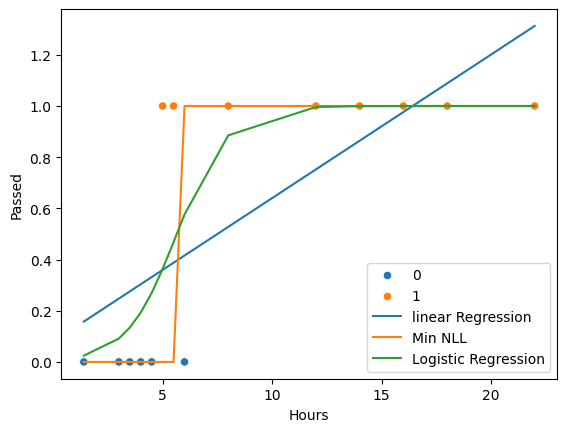

In [13]:
logr = LogisticRegression()
logr.fit(X_train, y_train)
sns.scatterplot(x = X_train.squeeze(), y = y_train, hue = y_train)
sns.lineplot(x = X_train.squeeze(), y = lr.predict(X_train), label = 'linear Regression')
sns.lineplot(x = X_train.squeeze(), y = y_train_pred, label = 'Min NLL')
sns.lineplot(x = X_train.squeeze(), y = logr.predict_proba(X_train)[:, 1], label = 'Logistic Regression')

In [32]:
np.exp(-10000)

np.float64(0.0)

In [42]:
num = list(range(-10,0)) + list(range(0,11))
e = []
for i in num:
    e.append(1/(1+np.exp(-i)))

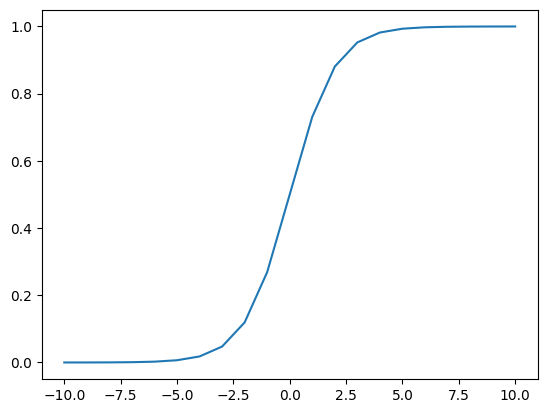

In [43]:
plt.plot(num,e)
plt.show()

In [27]:
e

[np.float64(4.5399929762484854e-05),
 np.float64(0.00012340980408667956),
 np.float64(0.00033546262790251185),
 np.float64(0.0009118819655545162),
 np.float64(0.0024787521766663585),
 np.float64(0.006737946999085467),
 np.float64(0.01831563888873418),
 np.float64(0.049787068367863944),
 np.float64(0.1353352832366127),
 np.float64(0.36787944117144233),
 np.float64(1.0),
 np.float64(2.718281828459045),
 np.float64(7.38905609893065),
 np.float64(20.085536923187668),
 np.float64(54.598150033144236),
 np.float64(148.4131591025766),
 np.float64(403.4287934927351),
 np.float64(1096.6331584284585),
 np.float64(2980.9579870417283),
 np.float64(8103.083927575384),
 np.float64(22026.465794806718)]